In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [68]:
class Indicator_Base():

    def __init__(self, start, end, amount):
        self.symbol = "BTC-USD"
        self.start = start
        self.end = end
        self.initial_balance = amount
        self.current_balance = amount
        self.units = 0
        self.get_data()

    def get_data(self):
        raw = pd.read_csv("btcusdt_1h.csv", parse_dates = ["datetime"], index_col = "datetime").dropna()
        raw.drop(columns=["open","high","low"], inplace = True)
        raw = raw.loc[self.start:self.end]
        raw["buy_n_hold_returns"] = np.log(raw.close / raw.close.shift(1))
        raw["Gains"] = np.where(raw.close.shift(1) - raw.close > 0, raw.close.shift(1) - raw.close, 0)
        raw["Loses"] = np.where(raw.close.shift(1) - raw.close < 0, raw.close - raw.close.shift(1), 0)
        self.data = raw

    def plot_data(self, cols = None):
        self.data["close"].plot(figsize = (12, 8), title = self.symbol)

    def plot_RSI(self, cols = None):
        self.data["RSI_Value"].plot(figsize = (12, 8), title = self.symbol)

    def get_values(self, bar):
        date = str(self.data.index[bar].date())
        price = round(self.data.close.iloc[bar], 5)
        return date, price

    def print_current_balance(self, bar):
        date, price = self.get_values(bar)
        print("{} | Current Balance: {}".format(date, round(self.current_balance, 2)))

    def buy_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance -= units * price
        self.units += units

    def sell_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance += units * price
        self.units -= units

    def close_pos(self, bar):
        date, price = self.get_values(bar)
        self.current_balance += self.units * price
        self.units = 0
        perf = (self.current_balance - self.initial_balance) / self.initial_balance * 100
        self.print_current_balance(bar)
        print("{} | net performance (%) = {}".format(date, round(perf, 2) ))

    def plot_results(self):
        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = "{} | Combined Indicator with look-back period of {}. ".format(self.symbol, "14 hours")
            self.results[["creturns", "cstrategy_returns","max_strategy_returns"]].plot(title=title, figsize=(12, 8))


class Indicator_Action(Indicator_Base):
    
    def go_long(self, bar, units = None, amount = None): #position is 1
        if self.position == -1: #previous position is short
            self.buy_instrument(bar, units = -self.units) # if short position, go neutral first
        if units:
            self.buy_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.buy_instrument(bar, amount = amount) # go long

    def go_short(self, bar, units = None, amount = None): #position is -1
        if self.position == 1: #previous position is long
            self.sell_instrument(bar, units = self.units) # if long position, go neutral first
        if units:
            self.sell_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.sell_instrument(bar, amount = amount)
            
    #use momentum to detect sudden volatility in the market
    def calculate_momentum(self, window):
        self.data['Momentum'] = self.data['close'] - self.data['close'].shift(int(window))
        return self.data

    # Plot Momentum
    def plot_momentum(self):
        plt.figure(figsize=(12, 8))
        plt.plot(self.data['Momentum'], label='Momentum', linewidth=2)
        plt.title('Momentum')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

    def test_ci_strategy(self, look_back):

        self.position = 0
        self.current_balance = self.initial_balance
        self.get_data()

        self.data["cGains"] = self.data["Gains"].rolling(look_back).sum()
        self.data["cLoses"] = self.data["Loses"].rolling(look_back).sum()
        self.data["RSI_Value"] = 100 - (100/(1+(self.data["cGains"]/self.data["cLoses"])))
        self.data = self.calculate_momentum(look_back/2)
        self.data.dropna(inplace = True)

        data = self.data.copy().dropna()

        for bar in range(len(data)-1):
            if data["RSI_Value"].iloc[bar] <= 12.5:                                      # RSI : [0,12.5]    <=> GO SHORT
                data.at[self.data.index[bar],"position"] = -1
            elif data["RSI_Value"].iloc[bar] <= 25 and data["Momentum"].iloc[bar] > 0:   # RSI : [12.5,25] with +ve momentum <=> GO LONG
                data.at[self.data.index[bar],"position"] = 1
            elif data["RSI_Value"].iloc[bar] <= 25 and data["Momentum"].iloc[bar] < 0:   # RSI : [12.5,25] with -ve momentum <=> GO LONG #special case
                data.at[self.data.index[bar],"position"] = 1
            elif data["RSI_Value"].iloc[bar] >= 87.5:                                    # RSI : [87.5,100]  <=> GO LONG 
                data.at[self.data.index[bar],"position"] = 1
            elif data["RSI_Value"].iloc[bar] >= 75 and data["Momentum"].iloc[bar] < 0:   # RSI : [75,87.5] with -ve momentum <=> GO SHORT
                data.at[self.data.index[bar],"position"] = -1
            elif data["RSI_Value"].iloc[bar] >= 75 and data["Momentum"].iloc[bar] > 0:   # RSI : [75,87.5] with +ve momentum <=> GO SHORT #special case
                data.at[self.data.index[bar],"position"] = -1
            elif data["RSI_Value"].iloc[bar] < 75 and data["RSI_Value"].iloc[bar] > 25:  # RSI : [25,75]     <=> GO NEUTRAL
                data.at[self.data.index[bar],"position"] = 0
            
        data["strategy_returns"] = data["position"].shift(1) * data["buy_n_hold_returns"]
        data.dropna(inplace=True)
        data["creturns"] = data["buy_n_hold_returns"].cumsum().apply(np.exp)
        data["cstrategy_returns"] = data["strategy_returns"].cumsum().apply(np.exp)
        data["max_strategy_returns"] = data["cstrategy_returns"].cummax()
        data["drawdown"] = ((data["max_strategy_returns"] - data["cstrategy_returns"])/data["max_strategy_returns"])*100
        self.results = data

        for bar in range(len(self.data)-1): # all bars (except the last bar)
            if self.position == 0:
                if self.data["RSI_Value"].iloc[bar] <= 12.5:
                    self.go_short(bar, amount = "all")
                    self.position = -1
                elif self.data["RSI_Value"].iloc[bar] < 25 and self.data["Momentum"].iloc[bar] > 0:
                    self.go_long(bar, amount = "all")
                    self.position = 1
                elif self.data["RSI_Value"].iloc[bar] >= 87.5:
                    self.go_long(bar, amount = "all")
                    self.position = 1
                elif self.data["RSI_Value"].iloc[bar] >= 75 and self.data["Momentum"].iloc[bar] < 0:
                    self.go_short(bar, amount = "all")
                    self.position = -1
            elif self.position == 1:
                if (self.data["RSI_Value"].iloc[bar] >= 75 and self.data["RSI_Value"].iloc[bar] < 87.5 and self.data["Momentum"].iloc[bar] < 0) or (self.data["RSI_Value"].iloc[bar] <= 12.5):
                        self.go_short(bar, amount = "all")
                        self.position = -1
                elif self.data["RSI_Value"].iloc[bar] > 25 and self.data["RSI_Value"].iloc[bar] < 75:
                        self.sell_instrument(bar, units = self.units)
                        self.position = 0
            elif self.position == -1:
                if (self.data["RSI_Value"].iloc[bar] < 25 and self.data["RSI_Value"].iloc[bar] >= 12.5 and self.data["Momentum"].iloc[bar] > 0) or (self.data["RSI_Value"].iloc[bar] >= 87.5):
                    self.go_long(bar, amount = "all")
                    self.position = 1
                elif self.data["RSI_Value"].iloc[bar] > 25 and self.data["RSI_Value"].iloc[bar] < 75:
                    self.buy_instrument(bar, units = -self.units)
                    self.position = 0
        self.close_pos(bar+1) # close position at the last bar

In [69]:
tester = Indicator_Action("2018-01-01", "2022-12-31", 100000)

In [70]:
tester.data

,close,volume,buy_n_hold_returns,Gains,Loses
datetime,,,,,
2018-01-01 05:30:00,13529.01,443.356199,NaN,0.00,0.00
2018-01-01 06:30:00,13203.06,383.697006,-0.024388,325.95,0.00
2018-01-01 07:30:00,13330.18,429.064572,0.009582,0.00,127.12
2018-01-01 08:30:00,13410.03,420.087030,0.005972,0.00,79.85
2018-01-01 09:30:00,13601.01,340.807329,0.014141,0.00,190.98
...,...,...,...,...,...
2022-01-12 01:30:00,42800.38,1219.601780,-0.004003,171.67,0.00
2022-01-12 02:30:00,42659.20,702.103800,-0.003304,141.18,0.00
2022-01-12 03:30:00,42713.13,561.859930,0.001263,0.00,53.93


In [71]:
tester.test_ci_strategy(14)

2022-01-12 | Current Balance: 297980.23
2022-01-12 | net performance (%) = 197.98


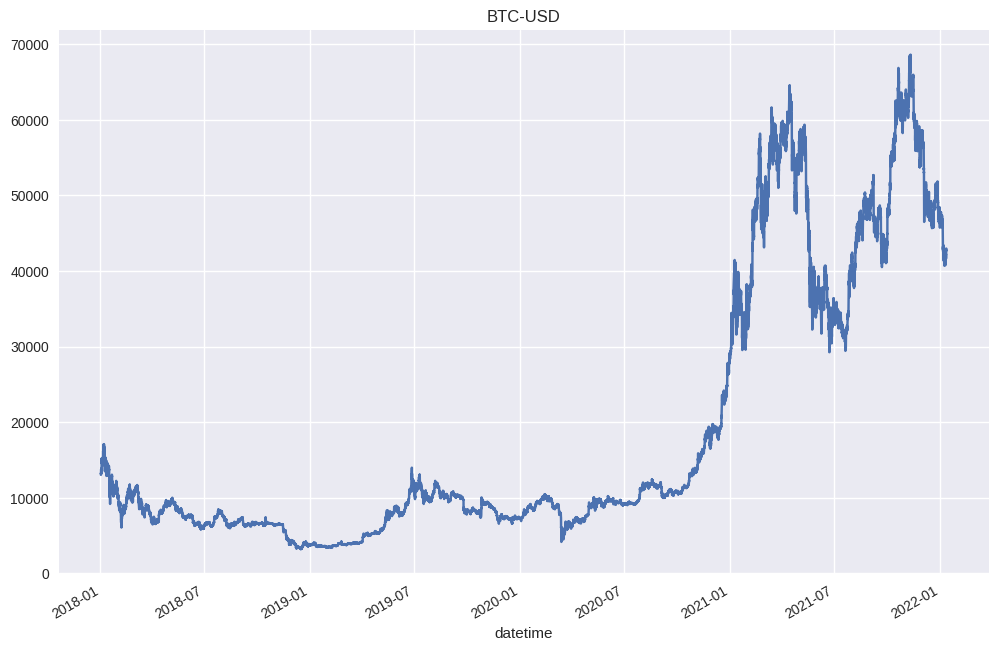

In [72]:
tester.plot_data()

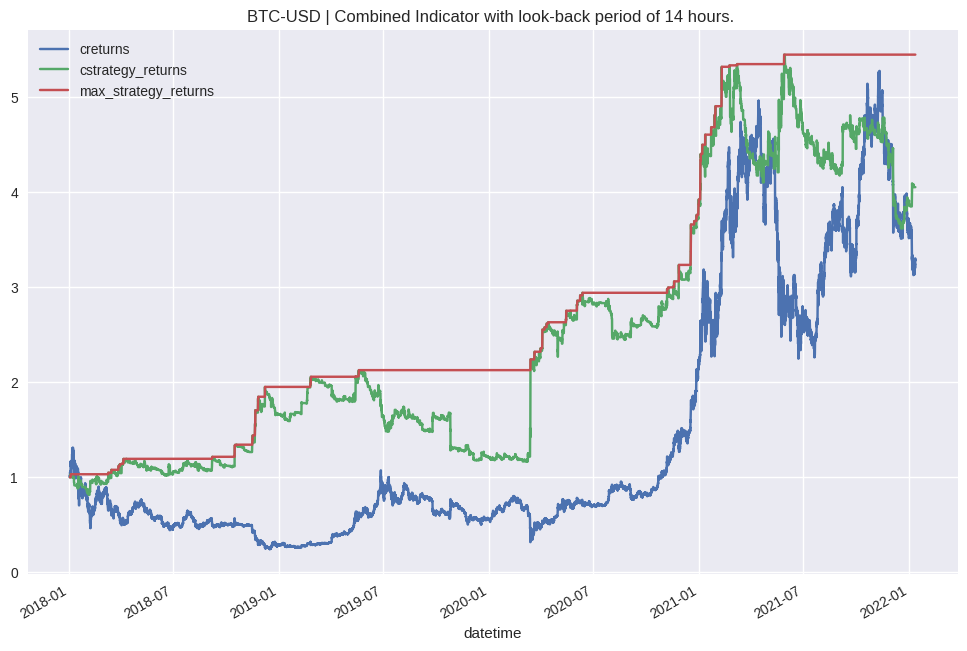

In [73]:
tester.plot_results()

In [74]:
tester.results

,close,volume,buy_n_hold_returns,Gains,Loses,cGains,cLoses,RSI_Value,Momentum,position,strategy_returns,creturns,cstrategy_returns,max_strategy_returns,drawdown
datetime,,,,,,,,,,,,,,,
2018-01-01 19:30:00,13211.39,692.467362,0.014823,0.00,194.39,1248.38,930.76,57.287737,-358.96,0.0,0.0,1.014934,1.000000,1.000000,0.000000
2018-01-01 20:30:00,13247.00,427.071957,0.002692,0.00,35.61,922.43,966.37,48.836828,-252.99,0.0,0.0,1.017669,1.000000,1.000000,0.000000
2018-01-01 21:30:00,13018.00,367.393566,-0.017438,229.00,0.00,1151.43,839.25,57.841039,-598.99,0.0,-0.0,1.000077,1.000000,1.000000,0.000000
2018-01-01 22:30:00,13022.00,228.572028,0.000307,0.00,4.00,1151.43,763.40,60.132231,-548.01,0.0,0.0,1.000384,1.000000,1.000000,0.000000
2018-01-01 23:30:00,13135.00,244.366755,0.008640,0.00,113.00,1151.43,685.42,62.685031,-85.56,0.0,0.0,1.009065,1.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-12 00:30:00,42972.05,1440.445690,0.005064,0.00,217.05,911.95,1774.00,33.952605,1159.36,0.0,0.0,3.301225,4.050157,5.443356,25.594488
2022-01-12 01:30:00,42800.38,1219.601780,-0.004003,171.67,0.00,1078.62,1774.00,37.811556,1098.86,0.0,-0.0,3.288037,4.050157,5.443356,25.594488
2022-01-12 02:30:00,42659.20,702.103800,-0.003304,141.18,0.00,1219.80,1667.95,42.240499,1017.20,0.0,-0.0,3.277191,4.050157,5.443356,25.594488


In [75]:
tester.results.drawdown.max()

45.27438669122888

In [76]:
tester.results.drawdown[tester.results.drawdown>46]  
#Maximum drawdown around 2020-01

Series([], Name: drawdown, dtype: float64)

In [81]:
#generate csv with only position and date time

tester.results.to_csv("RSI_Momentum.csv")

#position_combined consists of datetime and position
position_combined = tester.results[["position"]].copy()
position_combined

,position
datetime,
2018-01-01 19:30:00,0.0
2018-01-01 20:30:00,0.0
2018-01-01 21:30:00,0.0
2018-01-01 22:30:00,0.0
2018-01-01 23:30:00,0.0
...,...
2022-01-12 00:30:00,0.0
2022-01-12 01:30:00,0.0
2022-01-12 02:30:00,0.0
